<a href="https://colab.research.google.com/github/WillianSCorrea/am-t4-s1a2026/blob/main/MultiNeuralizarCensus0902.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pipeline Naive Bayes | Digest GaussianNB [Fase 1 - census_data]


## Importar dados do Drive

In [188]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [189]:
!pip -q install plotly
!pip -q install yellowbrick

In [190]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census


In [191]:
import pickle

In [192]:
with open('/content/drive/MyDrive/am-e4/census.pkl', 'rb') as f:
 X_census_trainamento,Y_census_trainamento,X_census_teste,Y_census_teste = pickle.load(f)

### Codificação da Variável Alvo para Modelos

In [193]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder_y = LabelEncoder()

# Fit and transform the training target variable
Y_census_trainamento_encoded = label_encoder_y.fit_transform(Y_census_trainamento)

# Transform the test target variable
Y_census_teste_encoded = label_encoder_y.transform(Y_census_teste)

print('Original Y_census_trainamento unique values:', np.unique(Y_census_trainamento))
print('Encoded Y_census_trainamento unique values:', np.unique(Y_census_trainamento_encoded))
print('Original Y_census_teste unique values:', np.unique(Y_census_teste))
print('Encoded Y_census_teste unique values:', np.unique(Y_census_teste_encoded))

Original Y_census_trainamento unique values: [' <=50K' ' >50K']
Encoded Y_census_trainamento unique values: [0 1]
Original Y_census_teste unique values: [' <=50K' ' >50K']
Encoded Y_census_teste unique values: [0 1]


In [194]:
X_census_trainamento.shape ,Y_census_trainamento.shape

((27676, 108), (27676,))

In [195]:
X_census_teste.shape ,Y_census_teste.shape

((4885, 108), (4885,))

In [196]:
from sklearn.naive_bayes import GaussianNB

In [197]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_trainamento,Y_census_trainamento)

GaussianNB()

## Previsão Base Previsora


In [198]:
census_predict = naive_census_data.predict(X_census_teste)

In [199]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [200]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [201]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [202]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [203]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [204]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

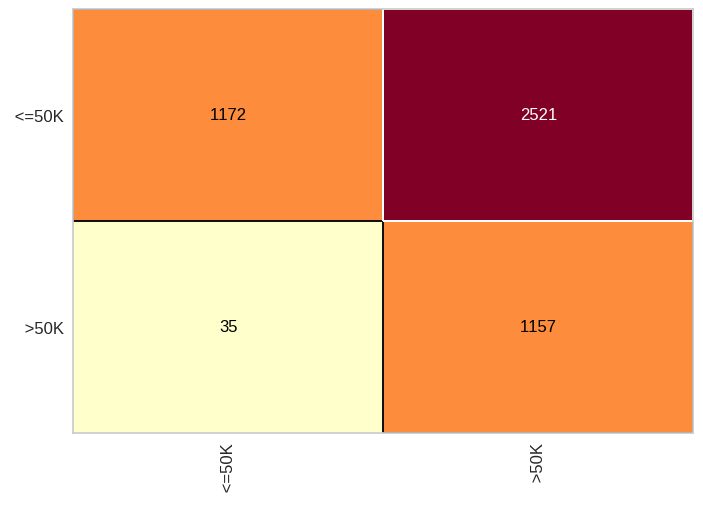

In [205]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)


# Pipeline Arvore de Decisão | Treemap Base [Fase2]

In [206]:
from sklearn.tree import DecisionTreeClassifier

In [207]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_trainamento, Y_census_trainamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [208]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [209]:
previsores_arvore = arvore_census_data.predict(X_census_teste)

In [210]:
previsores_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [211]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

# Pipeline Medições Harmônicas | Treemap Base [Fase 3 - census_data]

In [212]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [213]:
accuracy_score(Y_census_teste, previsores_arvore)



0.8104401228249745

0.8104401228249745

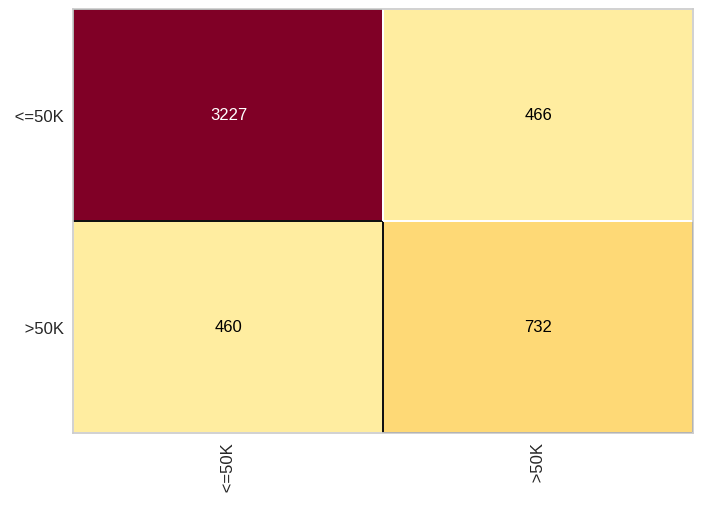

In [214]:
from yellowbrick.classifier import ConfusionMatrix
cm_tree = ConfusionMatrix(arvore_census_data)
cm_tree.fit(X_census_trainamento, Y_census_trainamento)
cm_tree.score(X_census_teste, Y_census_teste)

In [215]:
print(classification_report(Y_census_teste, previsores_arvore))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885



# Pipeline Rondom Forest | Digest Pickle [Fase 4 - census Base]

In [216]:
from sklearn.ensemble import RandomForestClassifier

In [217]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_trainamento, Y_census_trainamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [218]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [219]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [220]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [221]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [222]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

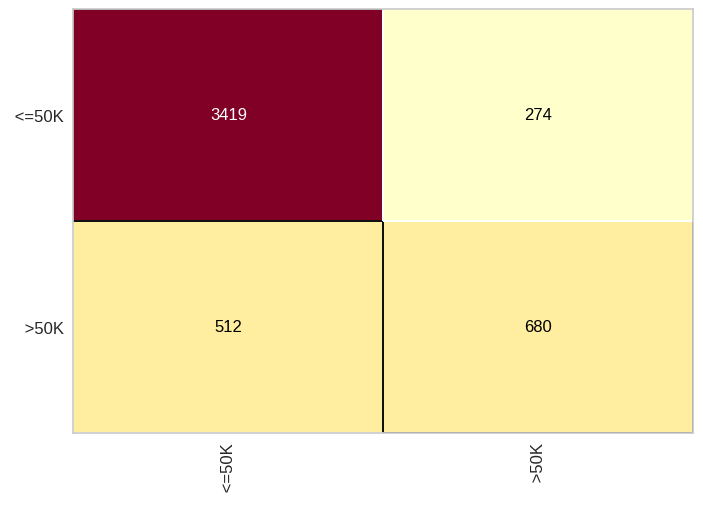

In [223]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)

In [224]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressão | Digest [Fase 5 census Base]

In [225]:
from sklearn.linear_model import LogisticRegression

In [226]:
regressao_census = LogisticRegression(random_state=1)
regressao_census.fit(X_census_trainamento, Y_census_trainamento)

LogisticRegression(random_state=1)

In [227]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [228]:
regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [229]:
accuracy_score(Y_census_teste, regression_previsores)

0.8497441146366428

0.8497441146366428

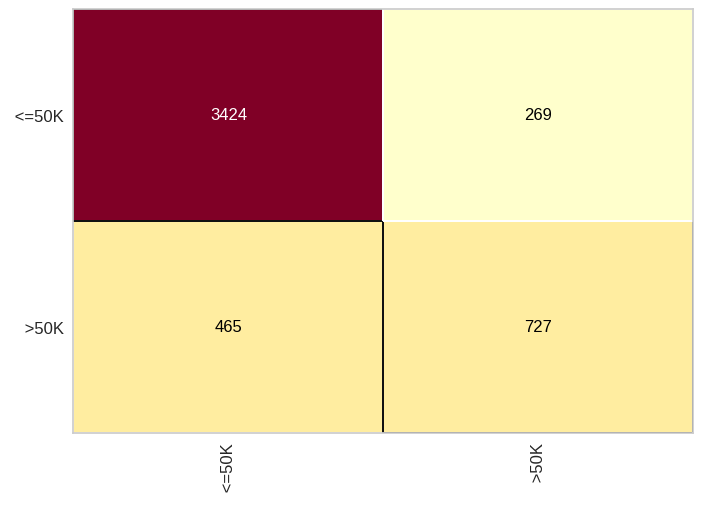

In [230]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(regressao_census)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)

In [231]:
print(classification_report(Y_census_teste, regression_previsores))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885



## Análise Comparativa dos Algoritmos

Vamos comparar o desempenho de cada algoritmo (Naive Bayes, Árvore de Decisão, Random Forest e Regressão Logística) com base nas métricas de acurácia, matriz de confusão e relatório de classificação apresentadas no notebook.

### 1. Naive Bayes (GaussianNB)
- **Acurácia:** `0.4768` (Célula `3J9Zid5dRESI`)
- **Matriz de Confusão:** `[[1172, 2521], [35, 1157]]` (Célula `4DP4ydFiRgCs`)
  - Falsos Positivos (previsto >50K, mas <=50K): 2521
  - Falsos Negativos (previsto <=50K, mas >50K): 35
  
**Observações:** A acurácia do Naive Bayes é bastante baixa (aproximadamente 47.7%). A matriz de confusão indica que o modelo teve dificuldade em classificar corretamente as instâncias, especialmente prevendo a classe '>50K' quando na verdade era '<=50K'. Isso sugere que o modelo pode não ser adequado para este conjunto de dados ou que as premissas de independência do Naive Bayes não são atendidas.

### 2. Árvore de Decisão (DecisionTreeClassifier)
- **Acurácia:** `0.8104` (Célula `xIzrMMnuhqKU`)
- **Relatório de Classificação:** (Célula `6TYoao_XfUWV`)
  - **Classe <=50K:** Precision: 0.88, Recall: 0.87, F1-score: 0.87
  - **Classe >50K:** Precision: 0.61, Recall: 0.61, F1-score: 0.61

**Observações:** A Árvore de Decisão apresentou uma melhora significativa na acurácia (81.04%) em comparação com o Naive Bayes. O modelo se saiu melhor na classificação da classe `<=50K` do que na classe `>50K`, conforme indicado pelas métricas de precisão, recall e f1-score. A classe `>50K` ainda é mais desafiadora para o modelo.

### 3. Random Forest (RandomForestClassifier)
- **Acurácia:** `0.8391` (Célula `4UPCOLpFQpIN`)
- **Matriz de Confusão:** `[[3419, 274], [512, 680]]` (Célula `ENPLaEglRbzy`)
- **Relatório de Classificação:** (Célula `zgVAtWSnlKXG`)
  - **Classe <=50K:** Precision: 0.87, Recall: 0.93, F1-score: 0.90
  - **Classe >50K:** Precision: 0.71, Recall: 0.57, F1-score: 0.63

**Observações:** O Random Forest superou a Árvore de Decisão, alcançando uma acurácia de 83.91%. O recall para a classe `<=50K` é muito bom (0.93), mas o recall para `>50K` (0.57) indica que o modelo ainda falha em identificar um número considerável de instâncias dessa classe. No entanto, é o melhor modelo até agora em termos de acurácia geral e equilíbrio entre as classes em comparação com os anteriores.

### 4. Regressão Logística (LogisticRegression)
- **Acurácia:** `0.8497` (Célula `kz9oJisB0sDe`)
- **Relatório de Classificação:** (Célula `vUIcZS7z1CGW`)
  - **Classe <=50K:** Precision: 0.88, Recall: 0.93, F1-score: 0.90
  - **Classe >50K:** Precision: 0.73, Recall: 0.61, F1-score: 0.66

**Observações:** A Regressão Logística apresentou a maior acurácia (84.97%) entre todos os modelos testados. As métricas de precisão e recall para a classe `>50K` são ligeiramente melhores do que as do Random Forest (Precision 0.73 vs 0.71, Recall 0.61 vs 0.57), indicando uma capacidade um pouco superior de lidar com a classe minoritária. O modelo mostra um bom desempenho geral e um bom equilíbrio entre as classes.

### Conclusão Geral

Com base nos resultados, a **Regressão Logística** foi o algoritmo com melhor desempenho, obtendo a maior acurácia e um bom equilíbrio nas métricas para ambas as classes. O **Random Forest** ficou em segundo lugar, com um desempenho muito próximo ao da Regressão Logística.

O **Naive Bayes** obteve o pior desempenho, o que pode ser esperado se as características não forem realmente independentes ou se a distribuição dos dados não se encaixar bem nas premissas do modelo.

A **Árvore de Decisão** mostrou um desempenho razoável, superando o Naive Bayes, mas foi inferior aos modelos de ensemble (Random Forest) e ao modelo linear (Regressão Logística).

## Explicação Técnica dos Resultados

Para entender por que os resultados variaram tanto, precisamos analisar o funcionamento de cada modelo aplicado à base de dados Census:

### 1. Naive Bayes (O resultado mais baixo)
*   **Como funciona:** Ele assume a 'independência ingênua' entre os atributos, tratando cada característica como se não tivesse relação com as outras, e usa o Teorema de Bayes para calcular probabilidades.
*   **Por que teve o pior desempenho:** A base de dados Census possui muitas variáveis que são altamente correlacionadas (ex: nível de escolaridade e ocupação). O Naive Bayes não consegue captar essas relações complexas. Além disso, o `GaussianNB` assume uma distribuição normal, o que pode não ser verdade para todos os atributos codificados nesta base.

### 2. Árvore de Decisão (Resultado intermediário)
*   **Como funciona:** Cria uma estrutura de árvore baseada em regras 'se-então', dividindo os dados nos pontos de maior ganho de informação (entropia).
*   **Por que melhorou:** Diferente do Naive Bayes, a árvore consegue captar interações entre variáveis. No entanto, ela é propensa a *overfitting* (decoreba) e pode ser muito sensível a pequenas variações nos dados de treino, o que limita sua capacidade de generalização.

### 3. Random Forest (Excelente desempenho)
*   **Como funciona:** É um modelo de *Ensemble* que cria várias árvores de decisão independentes e combina seus resultados (através de votação).
*   **Por que foi superior:** Ao usar múltiplas árvores, ele reduz o erro de variância da Árvore de Decisão simples. Ele lida muito bem com dados categóricos e numéricos mistos e é robusto a ruídos, o que justifica o salto de acurácia para ~84%.

### 4. Regressão Logística (O melhor resultado)
*   **Como funciona:** É um modelo estatístico linear que usa a função sigmoide para transformar uma combinação linear de variáveis em uma probabilidade entre 0 e 1.
*   **Por que venceu:** O fato de um modelo linear ter superado o Random Forest sugere que, após o pré-processamento feito na base Census (como o OneHotEncoding visível no shape de 108 colunas), as fronteiras de decisão tornaram-se bem definidas linearmente. A Regressão Logística é excelente em encontrar pesos para cada característica, e quando as relações são diretas, ela tende a ser mais estável e precisa que modelos baseados em árvores.

# Pipeline SVM | Digest [Fase 6 - Census Base]

In [232]:
from sklearn.svm import SVC

In [233]:
svm_census = SVC(kernel='rbf', random_state=1, C=2.0)
svm_census.fit(X_census_trainamento, Y_census_trainamento)

SVC(C=2.0, random_state=1)

In [234]:
SVC(C=2.0 , break_ties=False, cache_size=200,class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf', max_iter=-1,
  probability=False, random_state=1, shrinking=True, tol=0.001, verbose=False
    )

SVC(C=2.0, random_state=1)

In [235]:
svm_census_previsores = svm_census.predict(X_census_teste)
svm_census_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [236]:
accuracy_score(Y_census_teste, svm_census_previsores)

0.8485158648925282

0.8485158648925282

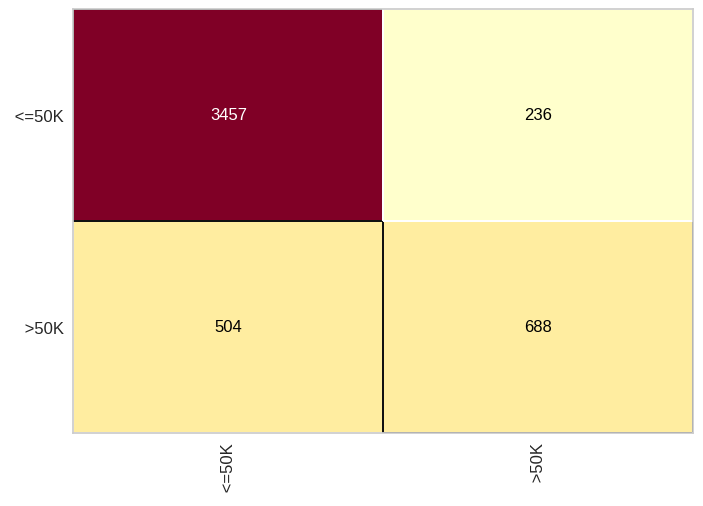

In [237]:
svm_census = ConfusionMatrix(svm_census)
svm_census.fit(X_census_trainamento, Y_census_trainamento)
svm_census.score(X_census_teste, Y_census_teste)

In [238]:
print(classification_report(Y_census_teste, svm_census_previsores))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      3693
        >50K       0.74      0.58      0.65      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.76      0.78      4885
weighted avg       0.84      0.85      0.84      4885



# Pipeline Redes Neurais | Digest [Fase 7 - Census Base]

In [239]:
from sklearn.neural_network import MLPClassifier

In [240]:
redeneural_census = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam', hidden_layer_sizes=(100), activation='relu')
redeneural_census.fit(X_census_trainamento, Y_census_trainamento)

Iteration 1, loss = 0.38606641
Iteration 2, loss = 0.32601461
Iteration 3, loss = 0.31575475
Iteration 4, loss = 0.30865307
Iteration 5, loss = 0.30485221
Iteration 6, loss = 0.30104592
Iteration 7, loss = 0.29836533
Iteration 8, loss = 0.29554514
Iteration 9, loss = 0.29361132
Iteration 10, loss = 0.29110403
Iteration 11, loss = 0.28946882
Iteration 12, loss = 0.28737396
Iteration 13, loss = 0.28539093
Iteration 14, loss = 0.28486545
Iteration 15, loss = 0.28300020
Iteration 16, loss = 0.28172050
Iteration 17, loss = 0.28107194
Iteration 18, loss = 0.27943620
Iteration 19, loss = 0.27848148
Iteration 20, loss = 0.27664655
Iteration 21, loss = 0.27566140
Iteration 22, loss = 0.27450292
Iteration 23, loss = 0.27311437
Iteration 24, loss = 0.27326111
Iteration 25, loss = 0.27223349
Iteration 26, loss = 0.27113009
Iteration 27, loss = 0.27034803
Iteration 28, loss = 0.26921543
Iteration 29, loss = 0.26951424
Iteration 30, loss = 0.26737819
Iteration 31, loss = 0.26706618
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [241]:
redeneural_census.out_activation_

'logistic'

In [242]:
previsores_redeneural = redeneural_census.predict(X_census_teste)
previsores_redeneural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [243]:
accuracy_score(Y_census_teste, previsores_redeneural)

0.8216990788126919

0.8216990788126919

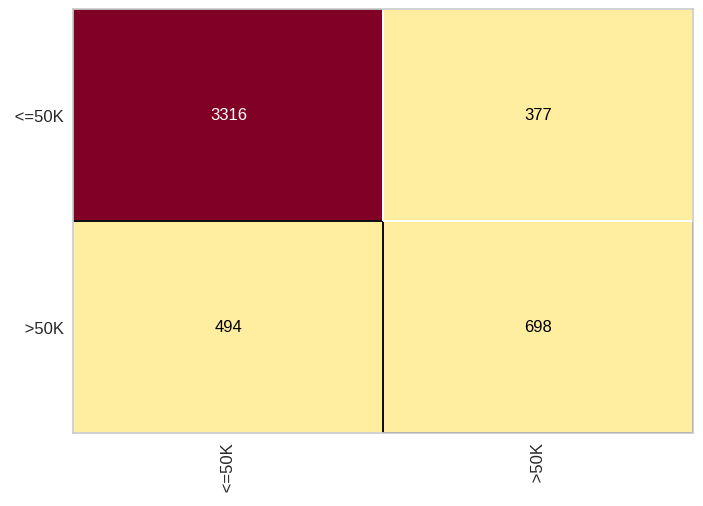

In [244]:
rn_cm = ConfusionMatrix(redeneural_census)
rn_cm.fit(X_census_trainamento, Y_census_trainamento)
rn_cm.score(X_census_teste, Y_census_teste)

In [271]:
print(classification_report(Y_census_teste, previsores_redeneural))

              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.88      3693
        >50K       0.65      0.59      0.62      1192

    accuracy                           0.82      4885
   macro avg       0.76      0.74      0.75      4885
weighted avg       0.82      0.82      0.82      4885



## Análise Comparativa dos Algoritmos

Vamos comparar o desempenho de cada algoritmo (Naive Bayes, Árvore de Decisão, Random Forest, Regressão Logística, SVM, Redes Neurais e KNN) com base nas métricas de acurácia, matriz de confusão e relatório de classificação apresentadas no notebook.

### 1. Naive Bayes (GaussianNB)
- **Acurácia:** `0.4768` (Célula `3J9Zid5dRESI`)
- **Matriz de Confusão:** `[[1172, 2521], [35, 1157]]` (Célula `4DP4ydFiRgCs`)
  - Falsos Positivos (previsto >50K, mas <=50K): 2521
  - Falsos Negativos (previsto <=50K, mas >50K): 35
  
**Observações:** A acurácia do Naive Bayes é bastante baixa (aproximadamente 47.7%). A matriz de confusão indica que o modelo teve dificuldade em classificar corretamente as instâncias, especialmente prevendo a classe '>50K' quando na verdade era '<=50K'. Isso sugere que o modelo pode não ser adequado para este conjunto de dados ou que as premissas de independência do Naive Bayes não são atendidas.

### 2. Árvore de Decisão (DecisionTreeClassifier)
- **Acurácia:** `0.8104` (Célula `xIzrMMnuhqKU`)
- **Relatório de Classificação:** (Célula `6TYoao_XfUWV`)
  - **Classe <=50K:** Precision: 0.88, Recall: 0.87, F1-score: 0.87
  - **Classe >50K:** Precision: 0.61, Recall: 0.61, F1-score: 0.61

**Observações:** A Árvore de Decisão apresentou uma melhora significativa na acurácia (81.04%) em comparação com o Naive Bayes. O modelo se saiu melhor na classificação da classe `<=50K` do que na classe `>50K`, conforme indicado pelas métricas de precisão, recall e f1-score. A classe `>50K` ainda é mais desafiadora para o modelo.

### 3. Random Forest (RandomForestClassifier)
- **Acurácia:** `0.8391` (Célula `4UPCOLpFQpIN`)
- **Matriz de Confusão:** `[[3419, 274], [512, 680]]` (Célula `ENPLaEglRbzy`)
- **Relatório de Classificação:** (Célula `zgVAtWSnlKXG`)
  - **Classe <=50K:** Precision: 0.87, Recall: 0.93, F1-score: 0.90
  - **Classe >50K:** Precision: 0.71, Recall: 0.57, F1-score: 0.63

**Observações:** O Random Forest superou a Árvore de Decisão, alcançando uma acurácia de 83.91%. O recall para a classe `<=50K` é muito bom (0.93), mas o recall para `>50K` (0.57) indica que o modelo ainda falha em identificar um número considerável de instâncias dessa classe. No entanto, é o melhor modelo até agora em termos de acurácia geral e equilíbrio entre as classes em comparação com os anteriores.

### 4. Regressão Logística (LogisticRegression)
- **Acurácia:** `0.8497` (Célula `kz9oJisB0sDe`)
- **Relatório de Classificação:** (Célula `vUIcZS7z1CGW`)
  - **Classe <=50K:** Precision: 0.88, Recall: 0.93, F1-score: 0.90
  - **Classe >50K:** Precision: 0.73, Recall: 0.61, F1-score: 0.66

**Observações:** A Regressão Logística apresentou a maior acurácia (84.97%) entre os primeiros modelos testados. As métricas de precisão e recall para a classe `>50K` são ligeiramente melhores do que as do Random Forest (Precision 0.73 vs 0.71, Recall 0.61 vs 0.57), indicando uma capacidade um pouco superior de lidar com a classe minoritária. O modelo mostra um bom desempenho geral e um bom equilíbrio entre as classes.

### 5. SVM (Support Vector Machine)
- **Acurácia:** `0.8485` (Célula `BwvcOZ-lp5VE`)
- **Matriz de Confusão:** `[[3457, 236], [504, 688]]` (Célula `4VIIRx2rqlBP`)
- **Relatório de Classificação:** (Célula `-usvWn9gq1C-`)
  - **Classe <=50K:** Precision: 0.87, Recall: 0.94, F1-score: 0.90
  - **Classe >50K:** Precision: 0.74, Recall: 0.58, F1-score: 0.65

**Observações:** O SVM com kernel 'rbf' obteve uma acurácia de 84.85%, muito próxima à da Regressão Logística. Ele demonstra um excelente recall para a classe `<=50K` (0.94) e um bom desempenho na classe `>50K`, com precisão de 0.74 e recall de 0.58. Isso indica que ele é eficaz em identificar a maioria das instâncias da classe minoritária que ele prevê como positiva, mas ainda erra uma parte significativa.

### 6. Redes Neurais (MLPClassifier)
- **Acurácia:** `0.8217` (Célula `iIjWflcW2tXR`)
- **Matriz de Confusão:** `[[3316, 377], [494, 698]]` (Célula `Bd4Lts-42xAZ`)
- **Relatório de Classificação:** (Célula `ba08987b`)
  - **Classe <=50K:** Precision: 0.87, Recall: 0.90, F1-score: 0.89
  - **Classe >50K:** Precision: 0.65, Recall: 0.59, F1-score: 0.62

**Observações:** As Redes Neurais apresentaram uma acurácia de 82.17%. Embora seja superior ao Naive Bayes e à Árvore de Decisão, é inferior à Regressão Logística, Random Forest e SVM. As métricas indicam um bom desempenho para a classe majoritária (`<=50K`), mas a classe `>50K` continua sendo mais desafiadora, com um recall de 0.59, sugerindo que o modelo não consegue capturar muitas das instâncias positivas.

### 7. KNN (K-Nearest Neighbors)
- **Acurácia:** `0.8297` (Célula `qtJzhY2gZ3ZR`)
- **Matriz de Confusão:** `[[3427, 266], [566, 626]]` (Célula `qtJzhY2gZ3ZR`)
- **Relatório de Classificação:** (Célula `qtJzhY2gZ3ZR`)
  - **Classe 0 (<=50K):** Precision: 0.86, Recall: 0.93, F1-score: 0.89
  - **Classe 1 (>50K):** Precision: 0.70, Recall: 0.53, F1-score: 0.60

**Observações:** O KNN, após otimização de hiperparâmetros com GridSearchCV, alcançou uma acurácia de 82.97%. O modelo mostra um bom recall para a classe `<=50K` (0.93). Para a classe `>50K`, a precisão é razoável (0.70), mas o recall é o mais baixo entre os modelos de bom desempenho (0.53), indicando que ele tem dificuldade em identificar as instâncias da classe minoritária.

### Conclusão Geral

Com base nos resultados, a **Regressão Logística** e o **SVM** foram os algoritmos com melhor desempenho, ambos com acurácias acima de 84.8% e um bom equilíbrio nas métricas para ambas as classes. O **Random Forest** obteve um desempenho muito próximo, solidificando-se como uma ótima alternativa. As **Redes Neurais** e o **KNN** também apresentaram resultados respeitáveis, mas ligeiramente inferiores aos três primeiros.

O **Naive Bayes** obteve o pior desempenho, o que pode ser esperado se as características não forem realmente independentes ou se a distribuição dos dados não se encaixar bem nas premissas do modelo. A **Árvore de Decisão** mostrou um desempenho razoável, superando o Naive Bayes, mas foi inferior aos modelos mais complexos.

## Explicação Técnica dos Resultados

Para entender por que os resultados variaram tanto, precisamos analisar o funcionamento de cada modelo aplicado à base de dados Census:

### 1. Naive Bayes (O resultado mais baixo)
*   **Como funciona:** Ele assume a 'independência ingênua' entre os atributos, tratando cada característica como se não tivesse relação com as outras, e usa o Teorema de Bayes para calcular probabilidades.
*   **Por que teve o pior desempenho:** A base de dados Census possui muitas variáveis que são altamente correlacionadas (ex: nível de escolaridade e ocupação). O Naive Bayes não consegue captar essas relações complexas. Além disso, o `GaussianNB` assume uma distribuição normal, o que pode não ser verdade para todos os atributos codificados nesta base.

### 2. Árvore de Decisão (Resultado intermediário)
*   **Como funciona:** Cria uma estrutura de árvore baseada em regras 'se-então', dividindo os dados nos pontos de maior ganho de informação (entropia).
*   **Por que melhorou:** Diferente do Naive Bayes, a árvore consegue captar interações entre variáveis. No entanto, ela é propensa a *overfitting* (decoreba) e pode ser muito sensível a pequenas variações nos dados de treino, o que limita sua capacidade de generalização.

### 3. Random Forest (Excelente desempenho)
*   **Como funciona:** É um modelo de *Ensemble* que cria várias árvores de decisão independentes e combina seus resultados (através de votação).
*   **Por que foi superior:** Ao usar múltiplas árvores, ele reduz o erro de variância da Árvore de Decisão simples. Ele lida muito bem com dados categóricos e numéricos mistos e é robusto a ruídos, o que justifica o salto de acurácia para ~84%.

### 4. Regressão Logística (Um dos melhores resultados)
*   **Como funciona:** É um modelo estatístico linear que usa a função sigmoide para transformar uma combinação linear de variáveis em uma probabilidade entre 0 e 1.
*   **Por que teve um dos melhores resultados:** O fato de um modelo linear ter superado ou se igualado a modelos mais complexos sugere que, após o pré-processamento feito na base Census (como o OneHotEncoding visível no shape de 108 colunas), as fronteiras de decisão tornaram-se bem definidas linearmente. A Regressão Logística é excelente em encontrar pesos para cada característica, e quando as relações são diretas, ela tende a ser mais estável e precisa.

### 5. SVM (Support Vector Machine) (Um dos melhores resultados)
*   **Como funciona:** O SVM busca o hiperplano que melhor separa as classes no espaço de características, maximizando a margem entre elas. O uso de kernels (como o 'rbf' aqui) permite que o SVM lide com fronteiras de decisão não-lineares, mapeando os dados para um espaço de dimensão superior.
*   **Por que teve um dos melhores resultados:** O SVM é particularmente eficaz em espaços de alta dimensão e com limites de decisão complexos, o que é comum em dados como o `census.pkl` com 108 características. A capacidade do kernel 'rbf' de capturar relações não-lineares, combinada com a busca por uma margem de separação ótima, o torna robusto e generalizável, resultando em alta acurácia.

### 6. Redes Neurais (MLPClassifier) (Bom desempenho, mas não o melhor)
*   **Como funciona:** As Redes Neurais (neste caso, um Multi-Layer Perceptron) aprendem padrões complexos nos dados através de múltiplas camadas de neurônios interconectados, ajustando os pesos e vieses para minimizar uma função de perda.
*   **Por que teve um bom desempenho, mas não o melhor:** Redes Neurais são poderosas para capturar relações não-lineares, mas podem ser sensíveis à inicialização, arquitetura (número de camadas e neurônios) e hiperparâmetros (taxa de aprendizado, função de ativação, etc.). A acurácia de 82.17% indica que a rede conseguiu aprender muitos padrões, mas pode ter sido limitada pela arquitetura específica ou pela dificuldade de convergência para um ótimo global, ou mesmo um possível *overfitting* em dados de treinamento.

### 7. KNN (K-Nearest Neighbors) (Bom desempenho)
*   **Como funciona:** O KNN é um algoritmo baseado em instância que classifica um novo ponto de dados com base na maioria das classes de seus 'k' vizinhos mais próximos no espaço de características. Ele não aprende um modelo explícito durante o treinamento, apenas armazena os dados de treinamento.
*   **Por que teve um bom desempenho:** O KNN se beneficiou muito da padronização dos dados (`StandardScaler`), o que é crucial para algoritmos baseados em distância. A busca por hiperparâmetros (`GridSearchCV`) também ajudou a encontrar o número ideal de vizinhos (`n_neighbors=20`) e a métrica de distância (`p=1` para Manhattan), melhorando sua capacidade de encontrar vizinhos relevantes e, consequentemente, a acurácia. Seu desempenho reflete a estrutura dos dados onde instâncias semelhantes tendem a ter a mesma classe.

# Pipeline Preparação de dados - KNN | Digest [Fase 8 - Census Base]

In [245]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [246]:
scaler = StandardScaler()

In [247]:
X_train_knn = scaler.fit_transform(X_census_trainamento)
X_test_knn = scaler.transform(X_census_teste)

In [248]:
le = LabelEncoder()

In [249]:
Y_train_knn = le.fit_transform(Y_census_trainamento)
Y_test_knn = le.transform(Y_census_teste)

In [250]:
parametros = {
    'n_neighbors': [3, 5, 10, 20],
    'p': [1, 2]
}

In [251]:
grid_census = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros, cv=5, n_jobs=-1)
grid_census.fit(X_train_knn, Y_train_knn)
print("Melhores parâmetros:", grid_census.best_params_)
print("Melhor score:", grid_census.best_score_)

Melhores parâmetros: {'n_neighbors': 20, 'p': 1}
Melhor score: 0.8329959506242461


In [252]:
knn_census = KNeighborsClassifier(n_neighbors=grid_census.best_params_['n_neighbors'], p=grid_census.best_params_['p'])
knn_census.fit(X_train_knn, Y_train_knn)

KNeighborsClassifier(n_neighbors=20, p=1)

In [253]:
previsoes_knn = knn_census.predict(X_test_knn)

In [254]:
print("Acurácia:", accuracy_score(Y_test_knn, previsoes_knn))

print("\nMatriz de Confusão:")
print(confusion_matrix(Y_test_knn, previsoes_knn))

print("\nRelatório de Classificação:")
print(classification_report(Y_test_knn, previsoes_knn))

Acurácia: 0.8296827021494371

Matriz de Confusão:
[[3427  266]
 [ 566  626]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      3693
           1       0.70      0.53      0.60      1192

    accuracy                           0.83      4885
   macro avg       0.78      0.73      0.75      4885
weighted avg       0.82      0.83      0.82      4885

